In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
import cv2


In [2]:
data_dir = r"C:\Users\Lenovo\Desktop\Exploration-of-ViT-and-CNN-for-Medical-Image-Processing\data\processed\segmentation\acute_lymphoblastic_leukemia_ALL"

# Check if path exists
if os.path.exists(data_dir):
    print("✅ Path exists:", data_dir)
    # List subdirectories (e.g., train, test, val)
    print("Subdirectories:", os.listdir(data_dir))
else:
    print("❌ Path not found!")

✅ Path exists: C:\Users\Lenovo\Desktop\Exploration-of-ViT-and-CNN-for-Medical-Image-Processing\data\processed\segmentation\acute_lymphoblastic_leukemia_ALL
Subdirectories: ['test', 'train', 'validation']


In [3]:
splits = ["train", "validation", "test"]
subtypes = ["Original", "Segmented"]

# Count images
for split in splits:
    print(f"\n📂 {split.upper()} set:")
    for subtype in subtypes:
        subtype_path = os.path.join(data_dir, split, subtype)
        if os.path.exists(subtype_path):
            print(f"  {subtype}:")
            for cls in os.listdir(subtype_path):
                class_path = os.path.join(subtype_path, cls)
                if os.path.isdir(class_path):
                    num_images = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
                    print(f"    {cls}: {num_images} images")
        else:
            print(f"  ⚠️ {subtype} folder not found in {split}")


📂 TRAIN set:
  Original:
    Benign: 352 images
    Early: 689 images
    Pre: 674 images
    Pro: 562 images
  Segmented:
    Benign: 352 images
    Early: 689 images
    Pre: 674 images
    Pro: 562 images

📂 VALIDATION set:
  Original:
    Benign: 76 images
    Early: 148 images
    Pre: 144 images
    Pro: 121 images
  Segmented:
    Benign: 76 images
    Early: 148 images
    Pre: 144 images
    Pro: 121 images

📂 TEST set:
  Original:
    Benign: 76 images
    Early: 148 images
    Pre: 145 images
    Pro: 121 images
  Segmented:
    Benign: 76 images
    Early: 148 images
    Pre: 145 images
    Pro: 121 images


In [4]:
counts = {
    "train": {"Benign": 352, "Early": 689, "Pre": 674, "Pro": 562},
    "validation": {"Benign": 76, "Early": 148, "Pre": 144, "Pro": 121},
    "test": {"Benign": 76, "Early": 148, "Pre": 145, "Pro": 121}
}


split_totals = {split: sum(class_counts.values()) for split, class_counts in counts.items()}
grand_total = sum(split_totals.values())

for split, total in split_totals.items():
    print(f"{split.capitalize()} total: {total} images")

print(f"\n📊 Grand Total: {grand_total} images")


Train total: 2277 images
Validation total: 489 images
Test total: 490 images

📊 Grand Total: 3256 images


In [5]:
for split, total in split_totals.items():
    percentage = (total / grand_total) * 100
    print(f"{split.capitalize()}: {total} images ({percentage:.2f}%)")

print(f"\n📊 Grand Total: {grand_total} images (100%)")


Train: 2277 images (69.93%)
Validation: 489 images (15.02%)
Test: 490 images (15.05%)

📊 Grand Total: 3256 images (100%)


In [7]:
%pip install mplcyberpunk

  Using cached mplcyberpunk-0.7.6-py3-none-any.whl.metadata (3.4 kB)
Using cached mplcyberpunk-0.7.6-py3-none-any.whl (6.5 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import os
import random
import matplotlib.pyplot as plt
import cv2
import mplcyberpunk

# Paths
train_original = os.path.join(data_dir, "train", "Original")
train_segmented = os.path.join(data_dir, "train", "Segmented")

In [9]:
random_class = random.choice(os.listdir(train_original))
print("Class chosen:", random_class)

Class chosen: Pre


In [10]:
img_name = random.choice(os.listdir(os.path.join(train_original, random_class)))
print("Image chosen:", img_name)

Image chosen: WBC-Malignant-Pre-571.jpg


In [11]:
orig_path = os.path.join(train_original, random_class, img_name)
segm_path = os.path.join(train_segmented, random_class, img_name)

orig_img = cv2.cvtColor(cv2.imread(orig_path), cv2.COLOR_BGR2RGB)
segm_img = cv2.cvtColor(cv2.imread(segm_path), cv2.COLOR_BGR2RGB)

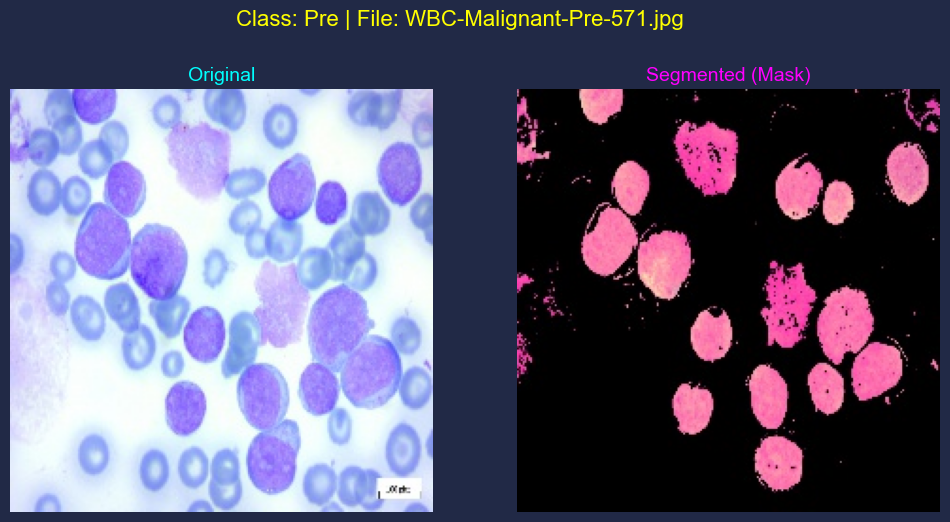

In [12]:
plt.style.use("cyberpunk")
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(orig_img)
axes[0].set_title("Original", fontsize=14, color="cyan")
axes[0].axis("off")

axes[1].imshow(segm_img)
axes[1].set_title("Segmented (Mask)", fontsize=14, color="magenta")
axes[1].axis("off")

plt.suptitle(f"Class: {random_class} | File: {img_name}", fontsize=16, color="yellow")
plt.show()

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import MeanIoU

In [22]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import MeanIoU
from tensorflow.keras.utils import Sequence

print("TF version:", tf.__version__)

TF version: 2.15.0


In [23]:
import tensorflow as tf

def iou_metric(y_true, y_pred):
    y_pred = tf.cast(y_pred > 0.5, tf.int32)
    y_true = tf.cast(y_true > 0.5, tf.int32)
    intersection = tf.reduce_sum(tf.cast(y_true * y_pred, tf.float32))
    union = tf.reduce_sum(tf.cast(y_true + y_pred, tf.float32)) - intersection
    return (intersection + 1e-7) / (union + 1e-7)

def dice_coefficient(y_true, y_pred, smooth=1e-7):
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    y_true = tf.cast(y_true > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth)

In [25]:
def unet_model(input_size=(128, 128, 3), num_classes=1):
    inputs = Input(input_size)

    # Encoder
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    c4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c4)
    p4 = layers.MaxPooling2D((2, 2))(c4)

    # Bottleneck
    c5 = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(p4)
    c5 = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(c5)

    # Decoder
    u6 = layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = layers.concatenate([u6, c4])
    c6 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c6)

    u7 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = layers.concatenate([u7, c3])
    c7 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c7)

    u8 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = layers.concatenate([u8, c2])
    c8 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u8)
    c8 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c8)

    u9 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = layers.concatenate([u9, c1])
    c9 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u9)
    c9 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c9)

    outputs = layers.Conv2D(num_classes, (1, 1), activation='sigmoid')(c9)

    model = models.Model(inputs=[inputs], outputs=[outputs])
    return model

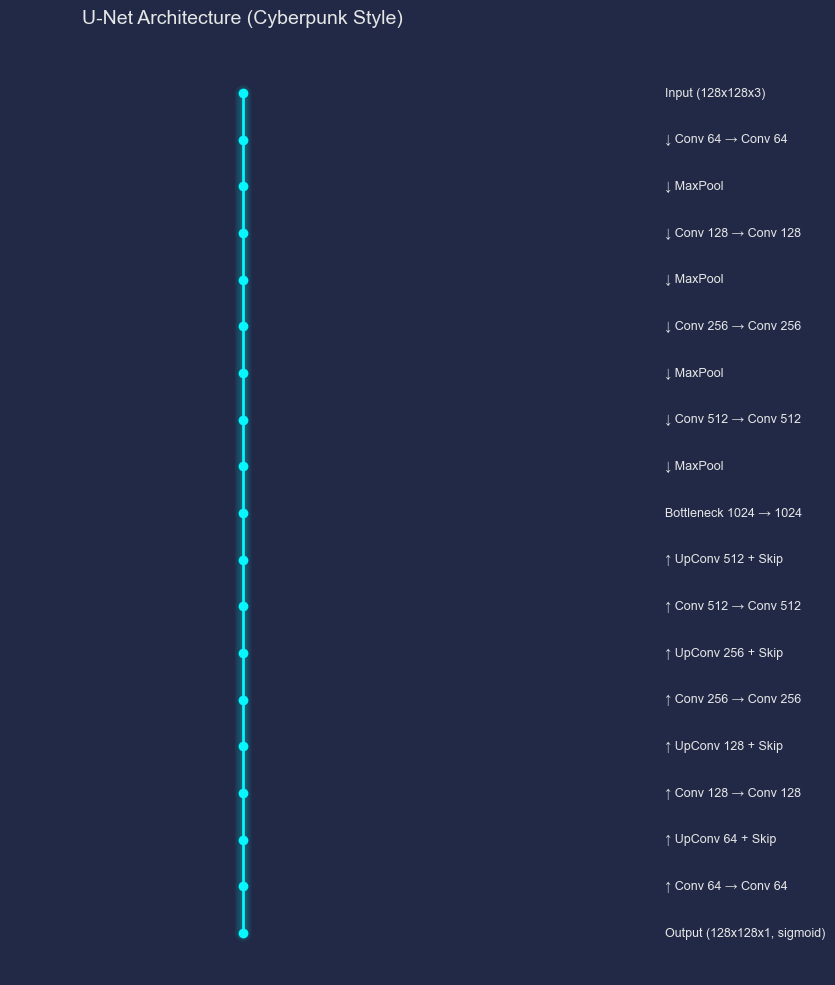

In [26]:
import matplotlib.pyplot as plt
import mplcyberpunk

def plot_unet_cyberpunk():
    layers = [
        "Input (128x128x3)",
        "↓ Conv 64 → Conv 64",
        "↓ MaxPool",
        "↓ Conv 128 → Conv 128",
        "↓ MaxPool",
        "↓ Conv 256 → Conv 256",
        "↓ MaxPool",
        "↓ Conv 512 → Conv 512",
        "↓ MaxPool",
        "Bottleneck 1024 → 1024",
        "↑ UpConv 512 + Skip",
        "↑ Conv 512 → Conv 512",
        "↑ UpConv 256 + Skip",
        "↑ Conv 256 → Conv 256",
        "↑ UpConv 128 + Skip",
        "↑ Conv 128 → Conv 128",
        "↑ UpConv 64 + Skip",
        "↑ Conv 64 → Conv 64",
        "Output (128x128x1, sigmoid)"
    ]

    y = list(range(len(layers)))[::-1] 
    x = [0]*len(layers)

    plt.figure(figsize=(6, 12))
    plt.plot(x, y, marker="o", linewidth=2)

    for i, layer in enumerate(layers):
        plt.text(0.1, y[i], layer, fontsize=9, ha="left", va="center")

    plt.title("U-Net Architecture (Cyberpunk Style)", fontsize=14, pad=20)
    plt.axis("off")


    plt.style.use("cyberpunk")
    mplcyberpunk.add_glow_effects()

    plt.show()

plot_unet_cyberpunk()


Compile model

In [27]:
model = unet_model(input_size=(128, 128, 3), num_classes=1)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",  # for binary masks
    metrics=["accuracy", iou_metric, dice_coefficient]
)

model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 128, 128, 3)]        0         []                            
                                                                                                  
 conv2d_19 (Conv2D)          (None, 128, 128, 64)         1792      ['input_2[0][0]']             
                                                                                                  
 conv2d_20 (Conv2D)          (None, 128, 128, 64)         36928     ['conv2d_19[0][0]']           
                                                                                                  
 max_pooling2d_4 (MaxPoolin  (None, 64, 64, 64)           0         ['conv2d_20[0][0]']           
 g2D)                                                                                       

Data Generator

In [28]:
IMG_SIZE = (128, 128)

class SegmentationDataGenerator(Sequence):
    def __init__(self, image_root, mask_root, batch_size=16):
        self.image_paths = []
        self.mask_paths = []
        self.batch_size = batch_size

        for subfolder in os.listdir(image_root):
            img_dir = os.path.join(image_root, subfolder)
            mask_dir = os.path.join(mask_root, subfolder)

            for fname in os.listdir(img_dir):
                self.image_paths.append(os.path.join(img_dir, fname))
                self.mask_paths.append(os.path.join(mask_dir, fname))

        self.indices = np.arange(len(self.image_paths))

    def __len__(self):
        return int(np.ceil(len(self.image_paths) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx*self.batch_size:(idx+1)*self.batch_size]
        X, y = [], []

        for i in batch_idx:
            img = cv2.imread(self.image_paths[i])
            img = cv2.resize(img, IMG_SIZE)
            img = img / 255.0

            mask = cv2.imread(self.mask_paths[i], cv2.IMREAD_GRAYSCALE)
            mask = cv2.resize(mask, IMG_SIZE)
            mask = mask / 255.0
            mask = np.expand_dims(mask, axis=-1)

            X.append(img)
            y.append(mask)

        return np.array(X), np.array(y)


In [29]:
data_dir = r"C:\Users\Lenovo\Desktop\Exploration-of-ViT-and-CNN-for-Medical-Image-Processing\data\processed\segmentation\acute_lymphoblastic_leukemia_ALL"

train_gen = SegmentationDataGenerator(
    image_root=os.path.join(data_dir, "train", "Original"),
    mask_root=os.path.join(data_dir, "train", "Segmented"),
    batch_size=16
)

val_gen = SegmentationDataGenerator(
    image_root=os.path.join(data_dir, "validation", "Original"),
    mask_root=os.path.join(data_dir, "validation", "Segmented"),
    batch_size=16
)

In [30]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20
)

Epoch 1/20
143/143 [==============================] - 641s 4s/step - loss: 0.2254 - accuracy: 0.7912 - iou_metric: 0.0011 - dice_coefficient: 0.0021 - val_loss: 0.1187 - val_accuracy: 0.7945 - val_iou_metric: 0.0698 - val_dice_coefficient: 0.1261
Epoch 2/20
143/143 [==============================] - 655s 5s/step - loss: 0.1102 - accuracy: 0.7913 - iou_metric: 0.3632 - dice_coefficient: 0.4771 - val_loss: 0.0984 - val_accuracy: 0.7938 - val_iou_metric: 0.4479 - val_dice_coefficient: 0.5687
Epoch 3/20
143/143 [==============================] - 638s 4s/step - loss: 0.0985 - accuracy: 0.7911 - iou_metric: 0.4667 - dice_coefficient: 0.5808 - val_loss: 0.0957 - val_accuracy: 0.7924 - val_iou_metric: 0.5423 - val_dice_coefficient: 0.6394
Epoch 4/20
143/143 [==============================] - 637s 4s/step - loss: 0.0946 - accuracy: 0.7910 - iou_metric: 0.4925 - dice_coefficient: 0.6036 - val_loss: 0.0909 - val_accuracy: 0.7934 - val_iou_metric: 0.5376 - val_dice_coefficient: 0.6404
Epoch 5/20
1